# Simulating Two body Orbit using LeapFrog's methods
## Asuumptions
*   1. Assume Sun is at center and earth is revolving around sun
    2. Consider GM = 1 (M= mass of sun,G= Gravitational constant)
    3. mass of earth = m =1
    4. initial position of earth= r = (1,0)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

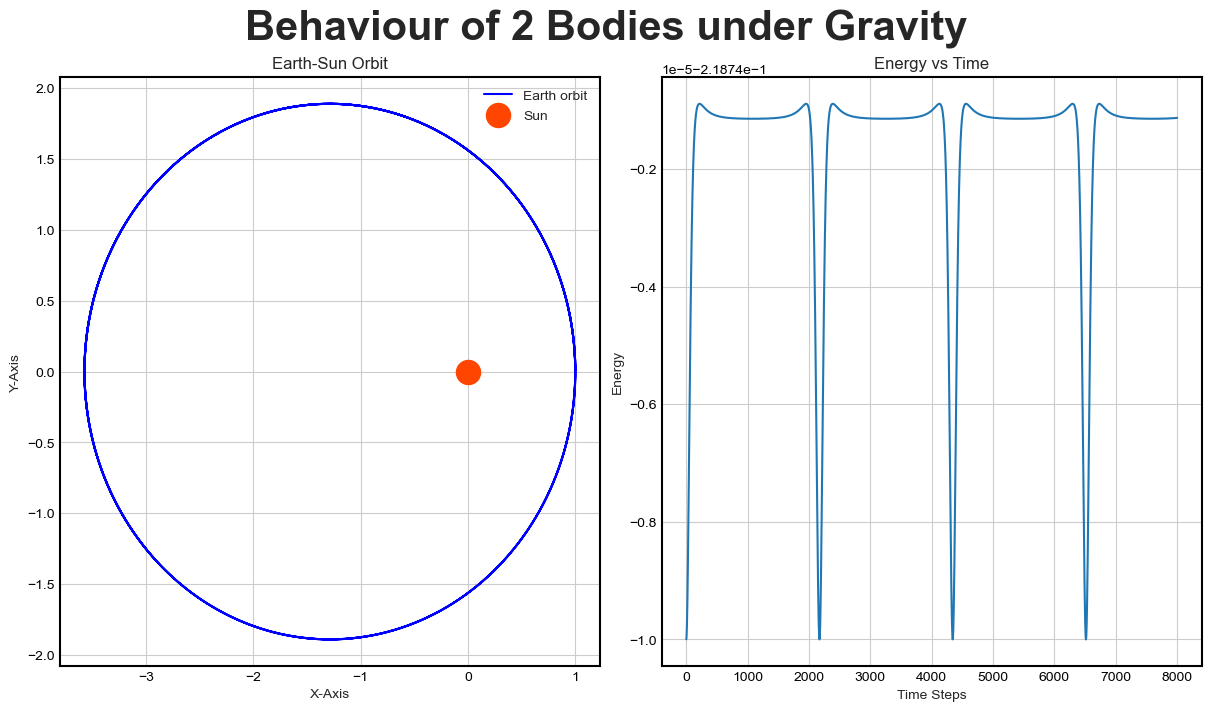

In [ ]:


    
# Initial conditions
r = np.array([1.00,0.00])


v = np.array([0.00,1.250])

def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -r/r_mag**3
    
positions = []

energies =   []

a =  acceleration(r)

#LeapFrog's methods

dt = 0.01
N = 8000

for w in range(N):
    
    v_halfstep = v + 0.5 * dt * a
    
    r = r + dt*v_halfstep
    
    a_new = acceleration(r)
    
    v = v_halfstep + 0.5 * dt * a_new
    
    a = a_new

    positions.append(r.copy())
    energy = (0.5 * np.dot(v,v)) - 1/np.linalg.norm(r)
    energies.append(energy)

positions = np.array(positions)
energies = np.array(energies)

## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,7),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of 2 Bodies under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)






# Behavior of Sun and Earth with real data


## Case 1 using equations of circular motion

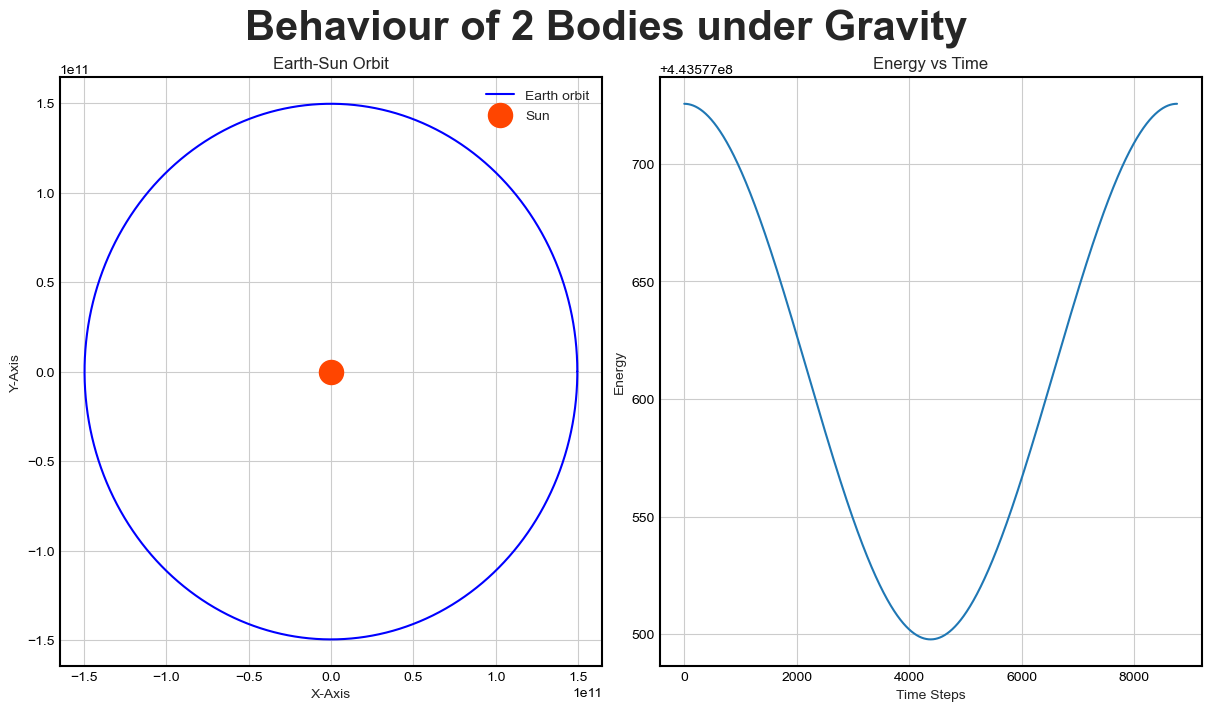

In [ ]:
# Initial conditions
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_sun = 1.9885e30     # kg


#Mean Orbital Radius of earth-sun system
r0 = 1.496e11   # meters
r = np.array([r0,0.00])

# Earth's Orbital velocity
v0 = np.sqrt(G * M_sun / r0)
v = np.array([0.00,v0]) #meters/sec

def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -G * M_sun * r / r_mag**3

    
positions = []

energies =   []

a =  acceleration(r)

#LeapFrog's methods

dt = 3600 # (1 Hour= 3600 sec)
N = int(365.25 * 24)   # hours in one year


for w in range(N):
    
    v_halfstep = v + 0.5 * dt * a
    
    r = r + dt*v_halfstep
    
    a_new = acceleration(r)
    
    v = v_halfstep + 0.5 * dt * a_new
    
    a = a_new

    positions.append(r.copy())
    energy = (0.5 * np.dot(v,v)) - 1/np.linalg.norm(r)
    energies.append(energy)

positions = np.array(positions)
energies = np.array(energies)

## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,7),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of 2 Bodies under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)










## Case 2: Real Earth's orbit, eccentricity = 0.0167
* assume starts at perihelion

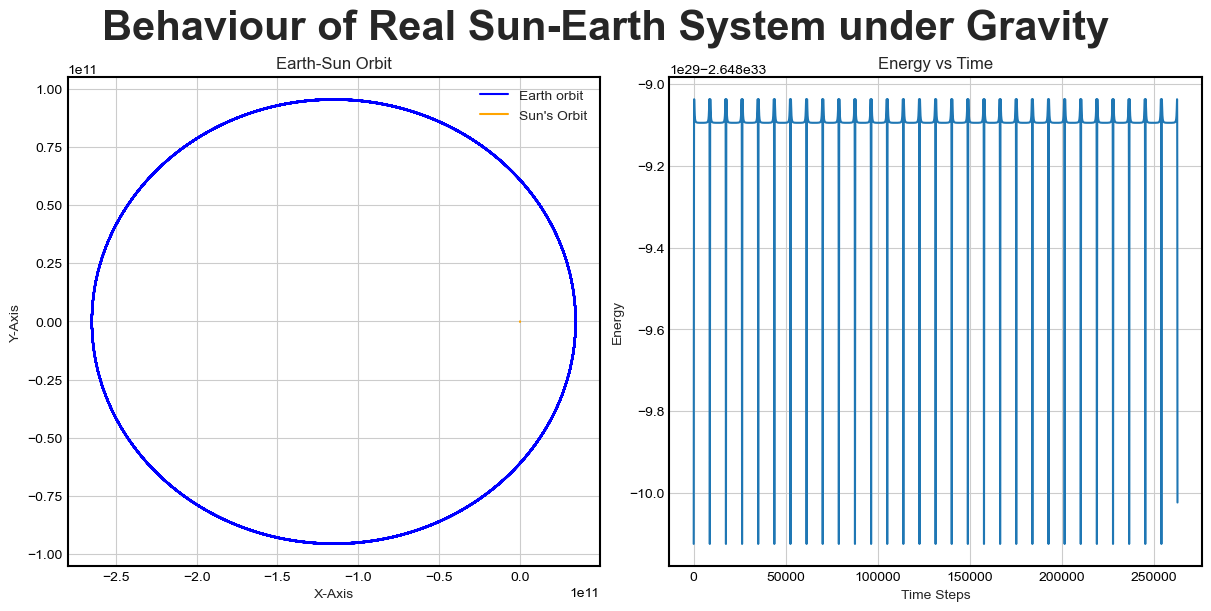

In [ ]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
aE= 1.496e11 # meters( Length of semi major axis of Earth)
eE=0.77




# Earth's Orbital velocity and Position
v0E = np.sqrt(G *M* (1 + eE)/(aE*(1 - eE)))
vE = np.array([0.00,v0E]) #meters/sec
rE = np.array([aE*(1-eE),0.00])



# Sun's initial parametrs
rS =  np.array([0.00,0.00])
vS = -(mE*vE)/M
# Barycentric conditions
Rcm = (mE*rE ) / (M + mE )
Vcm = (mE*vE )/ (M + mE )
rS = -Rcm
rE = rE - Rcm
vS = vS - Vcm
vE = vE - Vcm
rES = rE - rS



positions = []
positions_S = []
energies =   []

dt = 3600 #1 hour
N = 30*int(365.25 * 24)

for x in range(N):

    aE = (-G*M*rES/np.linalg.norm(rES)**3)

    aS = (G*mE*(rES)/np.linalg.norm(rES)**3)
    
    vE_half = vE + 0.5 * dt * aE
    vS_half = vS + 0.5 * dt * aS
    
    rE = rE + dt*vE_half
    rS = rS + dt*vS_half
    rES = rE - rS

    
    aE_new =  (-G*M*rES/np.linalg.norm(rES)**3)
    aS_new = (G*mE*(rES)/np.linalg.norm(rES)**3)

    vE = vE_half + 0.5 * dt * aE_new
    
    vS = vS_half + 0.5 * dt * aS_new
    
    aE = aE_new
    
    aS = aS_new

    positions.append(rE.copy())
    
    positions_S.append(rS.copy())
    energy = ((0.5*M*np.dot(vS,vS) + 0.5 *mE*np.dot(vE,vE)) - (G*M*mE/np.linalg.norm(rE-rS)))
    energies.append(energy.copy())

positions = np.array(positions)
positions_S = np.array(positions_S)
energies = np.array(energies)
    
## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0].plot(positions_S[:,0], positions_S[:,1], color = 'orange',label="Sun's Orbit")
ax[0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');



ax[0].legend(loc="upper right")

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Real Sun-Earth System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




# Case 3 : Letting eccentricity devolop naturally

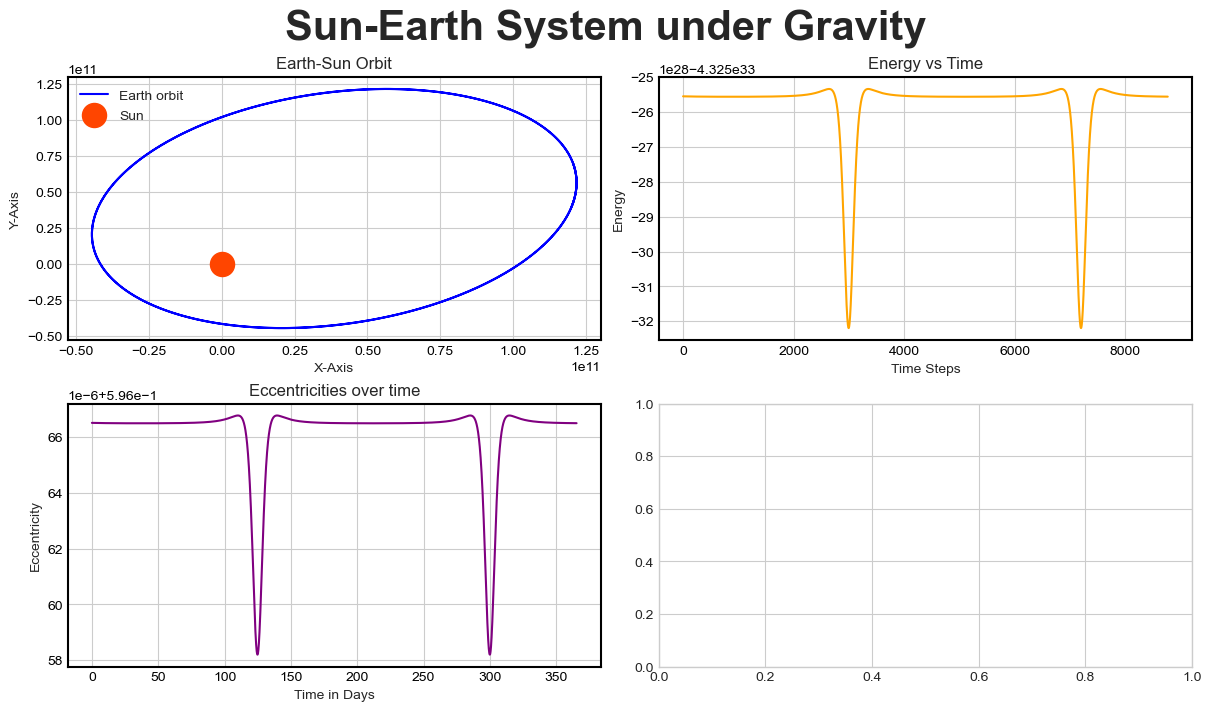

In [ ]:

# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M_sun = 1.9885e30 # kg
mE = 5.9722e24 #(mass of earth)
a = 1.496e11 # meters


r =  np.array([1.2e11,0.4e11,0.00])
v = np.array([5e3,2.5e4,0.00])


def acceleration(r):
    r_mag = np.linalg.norm(r)
    return -G * M_sun * r / r_mag**3


    
positions = []

energies =   []

eccentricities = []

a =  acceleration(r)

#LeapFrog's methods

dt = 3600 # (1 hour)

N = int(365.25 * 24)   # hours in one year


for w in range(N):
    
    v_halfstep = v + 0.5 * dt * a
    
    r = r + dt*v_halfstep
    
    a_new = acceleration(r)
    
    v = v_halfstep + 0.5 * dt * a_new
    
    a = a_new

    h = np.cross(r, v)              
    e_vec = np.cross(v, h)/(G*M_sun) - r/np.linalg.norm(r)
    e = np.linalg.norm(e_vec)
    eccentricities.append(e)

    positions.append(r.copy())
    energy = (0.5*mE*np.dot(v,v)) - G*M_sun*mE/np.linalg.norm(r)
    energies.append(energy)

positions = np.array(positions)
energies = np.array(energies)

## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=2
                       ,ncols=2,figsize=(12,7),constrained_layout=True)

ax[0,0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');

ax[0,0].set(title='Earth-Sun Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0,0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0,0].legend()

for spine in ax[0,0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0,0].tick_params(colors='#000000', width=1.2)


ax[0,1].plot(energies,color='orange')
ax[0,1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
for spine in ax[0,1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[0,1].tick_params(colors='#000000', width=1.2)

time = np.arange(N)*dt/(24*3600)

ax[1,0].plot(time,eccentricities,color='purple')
ax[1,0].set(title='Eccentricities over time',ylabel='Eccentricity',xlabel='Time in Days');
for spine in ax[1,0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1,0].tick_params(colors='#000000', width=1.2)
fig.suptitle('Sun-Earth System under Gravity', fontsize=30, fontweight='bold');











## KEY OBSERVATIONS
##### 1. velocity of the planet varies along the orbit, the eccentricity remains constant because it depends on a conserved combination of position and velocity (the Laplace–Runge–Lenz vector), which is preserved under an inverse-square central force

# Plotting 3 body orbits (SUN-EARTH-JUPYTER SYSTEM)

## CASE 1 : Jupyter is moving in fixed circular orbit around the Sun

* Assumptions 
1. sun at origin
2. force on jupyter due to earth is negligible
3. jupyter is not a dynamic system it follows a circular orbit around sun


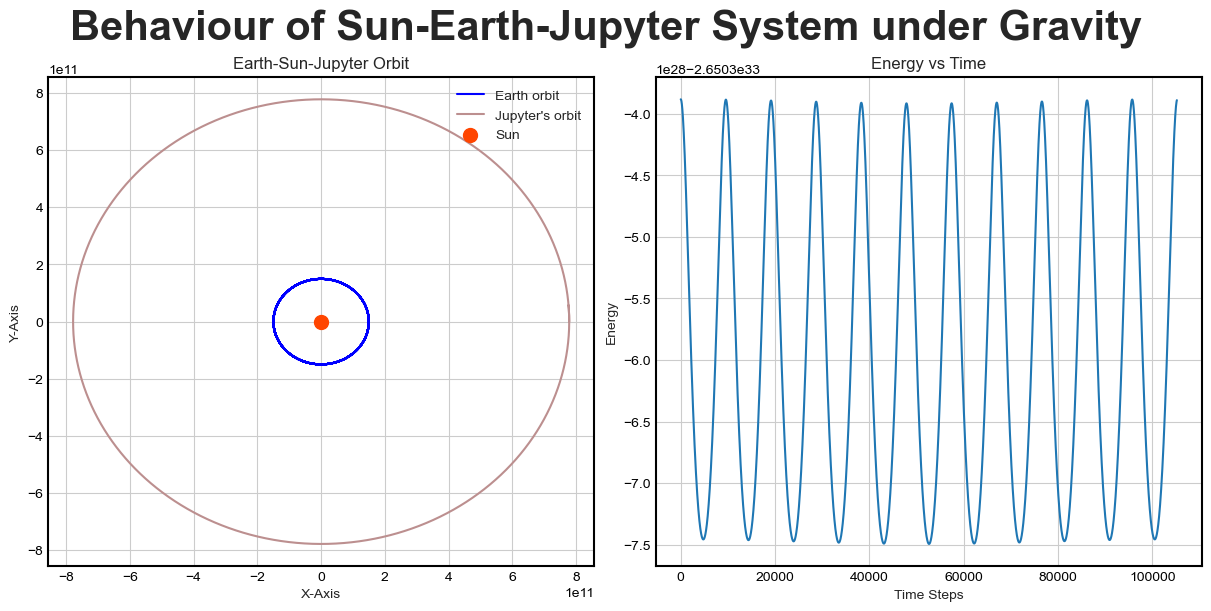

In [ ]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
mJ = 1.898e27 #kg(mass of jupyter)

#Mean Orbital Radius of earth-sun system
r0 = 1.496e11 # meters
rE = np.array([r0,0.00])




# Earth's Orbital velocity
v0 = np.sqrt(G * M/ r0)
vE = np.array([0.00,v0]) #meters/sec

r0J= 7.78E11

omegaJ = np.sqrt(G*M/r0J**3)

positions = []
positions_J = []

energies =   []

dt = 3600 #1 hour
N = 12*int(365.25 * 24)

for x in range(N):

    t = x*dt
    
    rJ = np.array([r0J * np.cos(omegaJ * t), r0J * np.sin(omegaJ * t)])

    aE = (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)

    v_halfstep = vE + 0.5 * dt * aE
    
    rE = rE + dt*v_halfstep
    
    a_new =  (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)
    
    vE = v_halfstep + 0.5 * dt * a_new
    a = a_new

    positions.append(rE.copy())
    positions_J.append(rJ.copy())
    energy = (0.5 *mE*np.dot(vE,vE)) - (G*M*mE/np.linalg.norm(rE)) - (G*mE*mJ/np.linalg.norm(rE-rJ))
    energies.append(energy)

positions = np.array(positions)
positions_J = np.array(positions_J)
energies = np.array(energies)
    
## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');
ax[0].plot(positions_J[:,0],positions_J[:,1], color= 'rosybrown',label="Jupyter's orbit");
ax[0].set(title='Earth-Sun-Jupyter Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=100,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Sun-Earth-Jupyter System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




# Case 2 : Real Dynamics of jupyter using leapfrog
* sun is still at centre and stationary
* energy is not conserved because

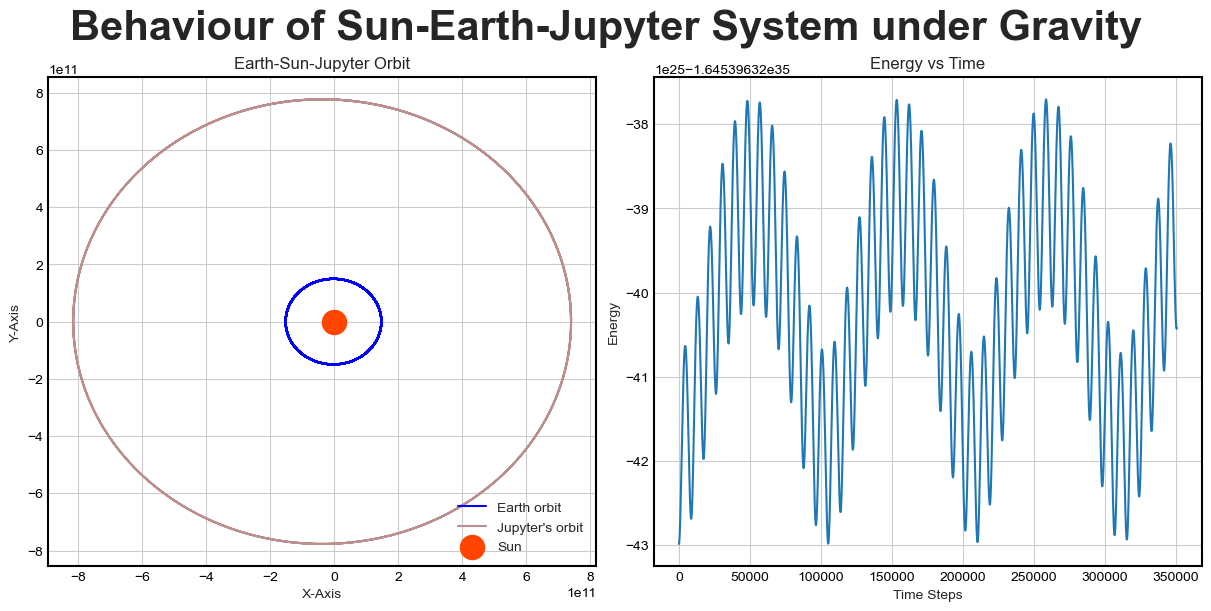

In [ ]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
mJ = 1.898e27 #kg(mass of jupyter)
aE= 1.496e11 # meters( Length of semi major axis of Earth)
aJ= 7.78e11 #meters(Length of semi major axis of Jupyter)
eE =  0.0167
eJ = 0.0489




# Earth's Orbital velocity and Position
v0E = np.sqrt(G *M* (1 + eE)/(aE*(1 - eE)))
vE = np.array([0.00,v0E]) #meters/sec
rE = np.array([aE*(1-eE),0.00])

# Jupyter's Orbital velocity and Position
v0J = np.sqrt(G*M*(1+eJ)/(aJ*(1-eJ)))
vJ = np.array([0.00,v0J])
rJ = np.array([aJ*(1-eJ),0.00])




positions = []
positions_J = []

energies =   []

dt = 3600 #1 hour
N = 40*int(365.25 * 24)

for x in range(N):

    aJ = (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)

    aE = (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)
    

    vE_half = vE + 0.5 * dt * aE
    vJ_half = vJ + 0.5 * dt * aJ
    
    rE = rE + dt*vE_half
    rJ = rJ + dt*vJ_half
    
    aE_new =  (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)
    aJ_new =  (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)

    vE = vE_half + 0.5 * dt * aE_new
    vJ = vJ_half + 0.5*dt*aJ_new
    a_E = aE_new
    a_J = aJ_new

    positions.append(rE.copy())
    positions_J.append(rJ.copy())
    energy = ((0.5 *mE*np.dot(vE,vE)) + 0.5*mJ*np.dot(vJ,vJ) - (G*M*mE/np.linalg.norm(rE)) - (G*mE*mJ/np.linalg.norm(rE-rJ)) - (G*M*mJ/np.linalg.norm(rJ)))
    energies.append(energy)

positions = np.array(positions)
positions_J = np.array(positions_J)
energies = np.array(energies)
    
## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');
ax[0].plot(positions_J[:,0],positions_J[:,1], color= 'rosybrown',label="Jupyter's orbit");
ax[0].set(title='Earth-Sun-Jupyter Orbit',xlabel='X-Axis',ylabel='Y-Axis');

ax[0].scatter(0, 0,color='orangered',s=300,label='Sun',zorder=3);

ax[0].legend()

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Sun-Earth-Jupyter System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




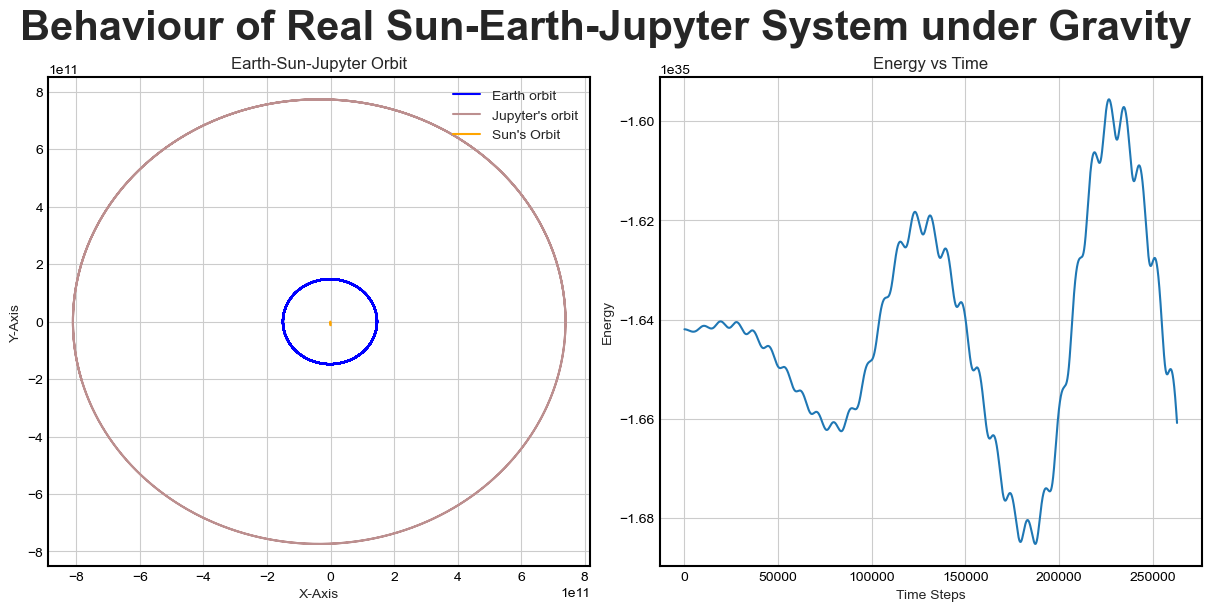

In [ ]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e30 # kg(mass of the sun)
mE = 5.9722e24 #(mass of earth)
mJ = 1.898e27 #kg(mass of jupyter)
aE= 1.496e11 # meters( Length of semi major axis of Earth)
aJ= 7.78e12 #meters(Length of semi major axis of Jupyter)
eE =  0.0167
eJ = 0.0489




# Earth's Orbital velocity and Position
v0E = np.sqrt(G *M* (1 + eE)/(aE*(1 - eE)))
vE = np.array([0.00,v0E]) #meters/sec
rE = np.array([aE*(1-eE),0.00])

# Jupiter's Orbital velocity and Position
v0J = np.sqrt(G*M*(1+eJ)/(aJ*(1-eJ)))
vJ = np.array([0.00,v0J])
rJ = np.array([aJ*(1-eJ),0.00])

# Sun's initial parametrs
rS =  np.array([0.00,0.00])
vS = -(mE*vE+mJ*vJ)/M
# Barycentric conditions
Rcm = (mE*rE + mJ*rJ) / (M + mE + mJ)
Vcm = (mE*vE + mJ*vJ)/ (M + mE + mJ)
rS = -Rcm
rE = rE - Rcm
rJ = rJ - Rcm
vS = vS - Vcm
vE = vE - Vcm
vJ = vJ - Vcm




positions = []
positions_J = []
positions_S = []
energies =   []

dt = 3600 #1 hour
N = 30*int(365.25 * 24)

for x in range(N):

    aJ = (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)

    aE = (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)

    aS = (-G*mE*(rS-rE)/np.linalg.norm(rS-rE)**3 - G*mJ*(rS-rJ)/np.linalg.norm(rS-rJ)**3)
    
    vE_half = vE + 0.5 * dt * aE
    vJ_half = vJ + 0.5 * dt * aJ
    vS_half = vS + 0.5 * dt * aS
    
    rE = rE + dt*vE_half
    rJ = rJ + dt*vJ_half
    rS = rS + dt*vS_half
    
    aE_new =  (-G*M*rE/np.linalg.norm(rE)**3 - G*mJ*(rE-rJ)/np.linalg.norm(rE-rJ)**3)
    aJ_new =  (-G*M*rJ/np.linalg.norm(rJ)**3 - G*mE*(rJ-rE)/np.linalg.norm(rJ-rE)**3)
    aS_new = (-G*mE*(rS-rE)/np.linalg.norm(rS-rE)**3 - G*mJ*(rS-rJ)/np.linalg.norm(rS-rJ)**3)

    vE = vE_half + 0.5 * dt * aE_new
    vJ = vJ_half + 0.5 * dt * aJ_new
    vS = vS_half + 0.5 * dt * aS_new
    
    aE = aE_new
    aJ = aJ_new
    aS = aS_new

    positions.append(rE.copy())
    positions_J.append(rJ.copy())
    positions_S.append(rS.copy())
    energy = ((0.5*M*np.dot(vS,vS) + 0.5 *mE*np.dot(vE,vE)) + 0.5*mJ*np.dot(vJ,vJ) - (G*M*mE/np.linalg.norm(rE-rS)) - (G*mE*mJ/np.linalg.norm(rE-rJ)) - (G*M*mJ/np.linalg.norm(rJ-rS)))
    energies.append(energy.copy())

positions = np.array(positions)
positions_J = np.array(positions_J)
positions_S = np.array(positions_S)
energies = np.array(energies)
    
## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions[:,0],positions[:,1],color='blue',label='Earth orbit');
ax[0].plot(positions_J[:,0],positions_J[:,1], color= 'rosybrown',label="Jupyter's orbit");
ax[0].plot(positions_S[:,0], positions_S[:,1], color = 'orange',label="Sun's Orbit")
ax[0].set(title='Earth-Sun-Jupyter Orbit',xlabel='X-Axis',ylabel='Y-Axis');



ax[0].legend(loc="upper right")

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of Real Sun-Earth-Jupyter System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




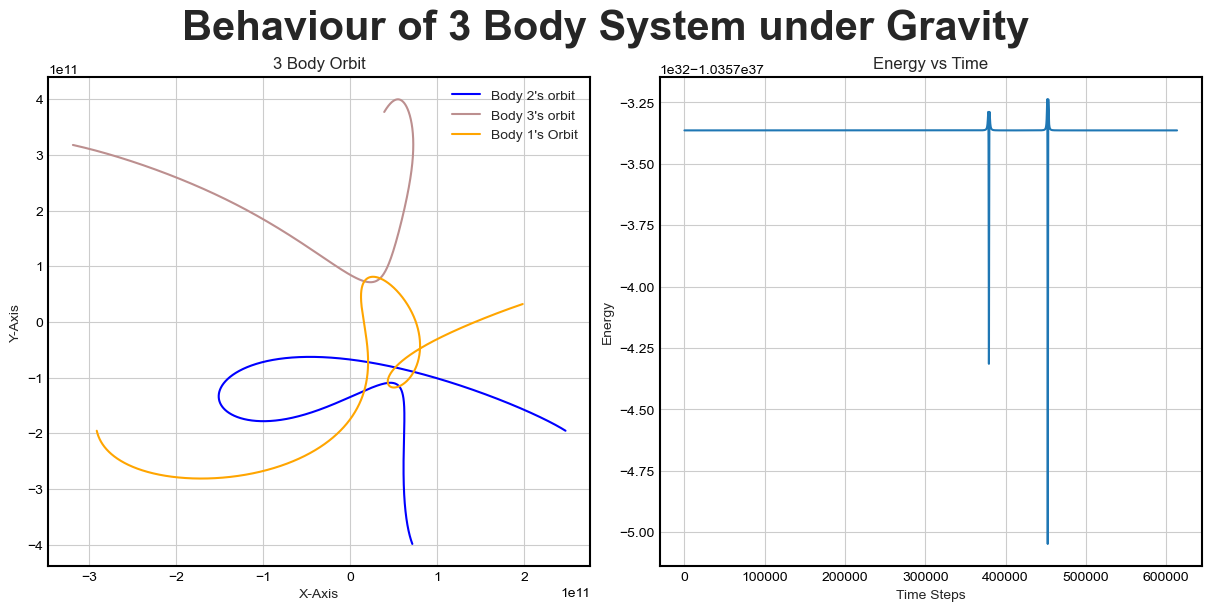

In [ ]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e29 # kg(mass of body 1)
m2 = 1.6722e29 #(mass of body 2)
m3 = 1.898e29 #kg(mass of body 3)
a2= 6.496e11 # meters( Length of semi major axis of body 2)
a3= 7.78e11 #meters(Length of semi major axis of body 3)
e2 =  0.17
e3 = 0.15





# Earth's Orbital velocity and Position
v02 = np.sqrt(G *M* (1 + e2)/(a2*(1 - e2)))
v2 = np.array([-0.56*v02,0.89*v02]) #meters/sec
r2 = np.array([a2*(1-e2), 0.0])
v2 *= 0.4

# Jupiter's Orbital velocity and Position
v03 = np.sqrt(G*M*(1+e3)/(a3*(1-e3)))
v3 = np.array([0.2*v03,v03])
r3 = np.array([a3*(1-e3)*np.cos(np.pi/3),
               a3*(1-e3)*np.sin(np.pi/3)])
v3 *= 0.5

# Sun's initial parametrs
r1 =  np.array([4.56e10,9.5e7])
v1 = -(m2*v2 + m3*v3)/M
v1 *= 0.4

# Barycentric conditions
Rcm = (M*r1 + m2*r2 + m3*r3) / (M + m2 + m3)
Vcm = (M*v1 + m2*v2 + m3*v3)/ (M + m2 + m3)
r1 = -Rcm
r2 = r2 - Rcm
r3 = r3 - Rcm
v1 = v1 - Vcm
v2 = v2 - Vcm
v3 = v3 - Vcm




positions_2 = []
positions_3 = []
positions_1 = []
energies =   []

dt = 300 #15 min
N = 70*int(365.25 * 24)

for x in range(N):

    a3 = (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3 - G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)

    a2 = (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3 - G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)

    a1 = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3 - G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)
    
    v2_half = v2 + 0.5 * dt * a2
    v3_half = v3 + 0.5 * dt * a3
    v1_half = v1 + 0.5 * dt * a1
    
    r2 = r2 + dt*v2_half
    r3 = r3 + dt*v3_half
    r1 = r1 + dt*v1_half
    
    a2_new =  (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3 - G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)
    a3_new =  (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3 - G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)
    a1_new = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3 - G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)

    v2 = v2_half + 0.5 * dt * a2_new
    v3 = v3_half + 0.5 * dt * a3_new
    v1 = v1_half + 0.5 * dt * a1_new
    
    a2 = a2_new
    a3 = a3_new
    a1 = a1_new

    positions_2.append(r2.copy())
    positions_3.append(r3.copy())
    positions_1.append(r1.copy())
    energy = ((0.5*M*np.dot(v1,v1) + 0.5 *m2*np.dot(v2,v2)) + 0.5*m3*np.dot(v3,v3) - (G*M*m2/np.linalg.norm(r2-r1)) - (G*m2*m3/np.linalg.norm(r2-r3)) - (G*M*m3/np.linalg.norm(r3-r1)))
    energies.append(energy.copy())

positions_2 = np.array(positions_2)
positions_3 = np.array(positions_3)
positions_1 = np.array(positions_1)
energies = np.array(energies)
    
## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions_2[:,0],positions_2[:,1],color='blue',label="Body 2's orbit");
ax[0].plot(positions_3[:,0],positions_3[:,1], color= 'rosybrown',label="Body 3's orbit");
ax[0].plot(positions_1[:,0], positions_1[:,1], color = 'orange',label="Body 1's Orbit")
ax[0].set(title='3 Body Orbit',xlabel='X-Axis',ylabel='Y-Axis');



ax[0].legend(loc="upper right")

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of 3 Body System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)

plt.savefig(r"C:\Users\satya\Desktop\3 body simulation\PLOTS\E LESS THAN 0\case1.png",
            dpi=300, bbox_inches='tight')




In [2]:
# Initial conditions
G = 6.67430e-11 # (N * m**2 /kg**2)
M = 1.9885e29 # kg(mass of body 1)
m2 = 1.6722e29 #(mass of body 2)
m3 = 1.898e29 #kg(mass of body 3)



# Earth's Orbital velocity and Position
v2 = np.array([  0.0, -1000.0])
r2 = np.array([ 3.0e11,  0.0])
v2 *= 0.4

# Jupiter's Orbital velocity and Position
v3 = np.array([-800.0,  0.0])
r3 = np.array([ 0.0,     4.5e11])


# Sun's initial parametrs
r1 = np.array([-3.0e11,  0.0])
v1 = np.array([  0.0,  1200.0])


# Barycentric conditions
Rcm = (M*r1 + m2*r2 + m3*r3) / (M + m2 + m3)
Vcm = (M*v1 + m2*v2 + m3*v3)/ (M + m2 + m3)
r1 = r1 - Rcm
r2 = r2 - Rcm
r3 = r3 - Rcm
v1 = v1 - Vcm
v2 = v2 - Vcm
v3 = v3 - Vcm

k = 0.8
v1 *= k
v2 *= k
v3 *= k

E0 = (
0.5*M*np.dot(v1,v1)
+0.5*m2*np.dot(v2,v2)
+0.5*m3*np.dot(v3,v3)
- G*M*m2/np.linalg.norm(r2-r1)
- G*M*m3/np.linalg.norm(r3-r1)
- G*m2*m3/np.linalg.norm(r2-r3)
)

print("Initial Energy:", E0)




positions_2 = []
positions_3 = []
positions_1 = []
energies =   []

dt = 300 #2 min
N = 4*int(365.25 * 24 * 30)

for x in range(N):

    a3 = (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3 - G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)

    a2 = (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3 - G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)

    a1 = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3 - G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)
    
    v2_half = v2 + 0.5 * dt * a2
    v3_half = v3 + 0.5 * dt * a3
    v1_half = v1 + 0.5 * dt * a1
    
    r2 = r2 + dt*v2_half
    r3 = r3 + dt*v3_half
    r1 = r1 + dt*v1_half
    
    a2_new =  (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3 - G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)
    a3_new =  (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3 - G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)
    a1_new = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3 - G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)

    v2 = v2_half + 0.5 * dt * a2_new
    v3 = v3_half + 0.5 * dt * a3_new
    v1 = v1_half + 0.5 * dt * a1_new
    
    a2 = a2_new
    a3 = a3_new
    a1 = a1_new

    positions_2.append(r2.copy())
    positions_3.append(r3.copy())
    positions_1.append(r1.copy())
    energy = ((0.5*M*np.dot(v1,v1) + 0.5 *m2*np.dot(v2,v2)) + 0.5*m3*np.dot(v3,v3) - (G*M*m2/np.linalg.norm(r2-r1)) - (G*m2*m3/np.linalg.norm(r2-r3)) - (G*M*m3/np.linalg.norm(r3-r1)))
    energies.append(energy.copy())

positions_2 = np.array(positions_2)
positions_3 = np.array(positions_3)
positions_1 = np.array(positions_1)
energies = np.array(energies)
    
## Plotting 
plt.style.use( 'seaborn-v0_8-whitegrid')


fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),constrained_layout=True)

ax[0].plot(positions_2[:,0],positions_2[:,1],color='blue',label="Body 2's orbit");
ax[0].plot(positions_3[:,0],positions_3[:,1], color= 'rosybrown',label="Body 3's orbit");
ax[0].plot(positions_1[:,0], positions_1[:,1], color = 'orange',label="Body 1's Orbit")
ax[0].set(title='3 Body Orbit',xlabel='X-Axis',ylabel='Y-Axis');



ax[0].legend(loc="upper right")

for spine in ax[0].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
    
ax[0].tick_params(colors='#000000', width=1.2)

ax[1].plot(energies)
ax[1].set(title='Energy vs Time',xlabel='Time Steps',ylabel='Energy');
fig.suptitle('Behaviour of 3 Body System under Gravity', fontsize=30, fontweight='bold')
for spine in ax[1].spines.values():
    spine.set_color('#000000')
    spine.set_linewidth(1.5)
ax[1].tick_params(colors='#000000', width=1.2)




NameError: name 'np' is not defined

In [ ]:
fig.savefig(r"C:\Users\satya\Desktop\3 body simulation\PLOTS\E LESS THAN 0\case0'.png",
            dpi=300, bbox_inches='tight')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# Constants
# -------------------------------------------------
G = 6.67430e-11
M = 1.9885e29
m2 = 1.6722e29
m3 = 1.898e29
theta = np.pi/6

dt = 300

T_total = 3* 365.25 * 24 * 3600
N = int(T_total / dt)

k = 0.8   # velocity scaling for bound energy

# -------------------------------------------------
# Create output folder
# -------------------------------------------------
save_dir = r"C:\Users\satya\Desktop\3 body simulation\PLOTS\E LESS THAN 0"
os.makedirs(save_dir, exist_ok=True)


# -------------------------------------------------
# Define 10 Chaotic Initial Condition Cases
# -------------------------------------------------
cases = [

# CASE 1
(
np.array([-1.2e11,  0.4e11]),
np.array([ 1.1e11, -0.5e11]),
np.array([ 0.3e11,  1.3e11]),
np.array([ 4500.0,  2500.0]),
np.array([-3500.0, -4200.0]),
np.array([ 1500.0, -3800.0])
),

# CASE 2
(
np.array([-1.0e11, -0.7e11]),
np.array([ 1.3e11,  0.2e11]),
np.array([-0.4e11,  1.2e11]),
np.array([ 4200.0,  3000.0]),
np.array([-4800.0, -2500.0]),
np.array([ 2000.0, -4200.0])
),

# CASE 3
(
np.array([1.2e11*np.cos(theta), 1.2e11*np.sin(theta)]),
np.array([1.2e11*np.cos(theta+2*np.pi/3), 1.2e11*np.sin(theta+2*np.pi/3)]),
np.array([1.2e11*np.cos(theta+4*np.pi/3), 1.2e11*np.sin(theta+4*np.pi/3)]),
np.array([-5200.0,  2000.0]),
np.array([ 4500.0, -3000.0]),
np.array([-2800.0, -4000.0])
),

# CASE 4
(
np.array([-1.1e11, 0.0]),
np.array([ 1.1e11, 0.0]),
np.array([ 0.0,    1.4e11]),
np.array([ 0.0,  6000.0]),
np.array([ 0.0, -5200.0]),
np.array([-4000.0, 2000.0])
),

# CASE 5
(
np.array([-1.0e11,  0.7e11]),
np.array([ 1.2e11, -0.6e11]),
np.array([-0.3e11,  1.5e11]),
np.array([ 4800.0, 2000.0]),
np.array([-3500.0,-4500.0]),
np.array([ 2000.0,-3800.0])
),

# CASE 6
(
np.array([-1.3e11,  0.3e11]),
np.array([ 1.0e11, -0.4e11]),
np.array([ 0.2e11,  1.4e11]),
np.array([ 4200.0, 4200.0]),
np.array([-4500.0,-3500.0]),
np.array([ 2500.0,-4000.0])
),

# CASE 7
(
np.array([-1.2e11,  0.9e11]),
np.array([ 1.3e11, -0.3e11]),
np.array([-0.4e11,  1.1e11]),
np.array([ 5200.0,  500.0]),
np.array([-4000.0,-4500.0]),
np.array([ 1500.0,-5000.0])
),

# CASE 8
(
np.array([-1.1e11, 0.0]),
np.array([ 1.1e11, 0.0]),
np.array([ 0.0,    1.4e11]),
np.array([ 0.0,  6500.0]),
np.array([ 0.0, -5500.0]),
np.array([-4500.0, 2500.0])
),

# CASE 9
(
np.array([-0.9e11,  0.8e11]),
np.array([ 1.4e11, -0.6e11]),
np.array([ 0.5e11,  1.3e11]),
np.array([ 5000.0,  500.0]),
np.array([-5200.0,-2000.0]),
np.array([ 2000.0,-4500.0])
),

# CASE 10
(
np.array([-1.2e11,  0.4e11]),
np.array([ 1.0e11, -0.9e11]),
np.array([ 0.4e11,  1.2e11]),
np.array([ 4800.0,  1800.0]),
np.array([-4200.0,-4200.0]),
np.array([ 2000.0,-4000.0])
)

]

# -------------------------------------------------
# SIMULATION LOOP FOR ALL CASES
# -------------------------------------------------

for i, case in enumerate(cases):

    r1 = case[0].copy()
    r2 = case[1].copy()
    r3 = case[2].copy()
    v1 = case[3].copy()
    v2 = case[4].copy()
    v3 = case[5].copy()

    # Barycentric correction
    Rcm = (M*r1 + m2*r2 + m3*r3)/(M+m2+m3)
    Vcm = (M*v1 + m2*v2 + m3*v3)/(M+m2+m3)

    r1 -= Rcm; r2 -= Rcm; r3 -= Rcm
    v1 -= Vcm; v2 -= Vcm; v3 -= Vcm

    v1 *= k; v2 *= k; v3 *= k

    positions_1 = []
    positions_2 = []
    positions_3 = []
    energies = []
    E0 = (
        0.5*M*np.dot(v1,v1)
        +0.5*m2*np.dot(v2,v2)
        +0.5*m3*np.dot(v3,v3)
        - G*M*m2/np.linalg.norm(r2-r1)
        - G*M*m3/np.linalg.norm(r3-r1)
        - G*m2*m3/np.linalg.norm(r2-r3))

    print("Initial Energy:", E0)

    for step in range(N):

        a1 = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3
          -G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)

        a2 = (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3
          -G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)

        a3 = (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3
          -G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)

        v1_half = v1 + 0.5*dt*a1
        v2_half = v2 + 0.5*dt*a2
        v3_half = v3 + 0.5*dt*a3

        r1 += dt*v1_half
        r2 += dt*v2_half
        r3 += dt*v3_half

        a1_new = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3
              -G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)

        a2_new = (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3
              -G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)

        a3_new = (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3
              -G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)

        v1 = v1_half + 0.5*dt*a1_new
        v2 = v2_half + 0.5*dt*a2_new
        v3 = v3_half + 0.5*dt*a3_new

        # ---- Energy Calculation ----
        energy = (
            0.5*M*np.dot(v1,v1)
            +0.5*m2*np.dot(v2,v2)
            +0.5*m3*np.dot(v3,v3)
            -G*M*m2/np.linalg.norm(r2-r1)
            -G*m2*m3/np.linalg.norm(r2-r3)
            -G*M*m3/np.linalg.norm(r3-r1)
        )

        if step % 10 == 0:
            positions_1.append(r1.copy())
            positions_2.append(r2.copy())
            positions_3.append(r3.copy())
            energies.append(energy)

    positions_1 = np.array(positions_1)
    positions_2 = np.array(positions_2)
    positions_3 = np.array(positions_3)
    energies = np.array(energies)

# -------------------------
# Plotting (Your Exact Style)
# -------------------------
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6), constrained_layout=True)

# Orbit Plot
    ax[0].plot(positions_2[:,0], positions_2[:,1], color='blue', label="Body 2's orbit")
    ax[0].plot(positions_3[:,0], positions_3[:,1], color='rosybrown', label="Body 3's orbit")
    ax[0].plot(positions_1[:,0], positions_1[:,1], color='orange', label="Body 1's orbit")

    ax[0].set(title='3 Body Orbit', xlabel='X-Axis', ylabel='Y-Axis')
    ax[0].legend(loc="upper right")

    for spine in ax[0].spines.values():
        spine.set_color('#000000')
        spine.set_linewidth(1.5)

    ax[0].tick_params(colors='#000000', width=1.2)

# Energy Plot
    ax[1].plot(energies)
    ax[1].set(title='Energy vs Time', xlabel='Time Steps', ylabel='Energy')

    for spine in ax[1].spines.values():
        spine.set_color('#000000')
        spine.set_linewidth(1.5)

    ax[1].tick_params(colors='#000000', width=1.2)

    fig.suptitle(f'Behaviour of 3 Body System under Gravity (Case {i+1})',
             fontsize=20, fontweight='bold')

    fig.savefig(os.path.join(save_dir, f"case_{i+1}.png"), dpi=300)
    plt.close(fig)

print("All 10 cases completed and saved.")


Initial Energy: -3.0538034903030023e+37
Initial Energy: -2.8109811494606985e+37
Initial Energy: -2.8810079170782984e+37
Initial Energy: -3.179757966125207e+37
Initial Energy: -3.6999542489271605e+37
Initial Energy: -2.8520098221826705e+37
Initial Energy: -4.455845635192428e+37
Initial Energy: -3.1050135678576985e+37
Initial Energy: -3.135146829216904e+37
Initial Energy: -2.8621638821736396e+37
All 10 cases completed and saved.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# Constants
# -------------------------------------------------
G = 6.67430e-11
M = 1.9885e29
m2 = 1.6722e29
m3 = 1.898e29
theta = np.pi/6

dt = 300

T_total = 3* 365.25 * 24 * 3600
N = int(T_total / dt)

k = 3  # velocity scaling for bound energy

# -------------------------------------------------
# Create output folder
# -------------------------------------------------
save_dir = r"C:\Users\satya\Desktop\3 body simulation\PLOTS\E GREATER THAN 0"
os.makedirs(save_dir, exist_ok=True)


# -------------------------------------------------
# Define 10 Chaotic Initial Condition Cases
# -------------------------------------------------
cases = [

# CASE 1
(
np.array([-1.0e11,  0.0]),
np.array([ 1.0e11,  0.0]),
np.array([ 0.0,     1.2e11]),
np.array([ 0.0,   9000.0]),
np.array([ 0.0,  -8500.0]),
np.array([-8000.0, 2000.0])
),

# CASE 2
(
np.array([-1.2e11,  0.5e11]),
np.array([ 1.1e11, -0.4e11]),
np.array([ 0.3e11,  1.3e11]),
np.array([ 9500.0,  3500.0]),
np.array([-8200.0, -6000.0]),
np.array([ 7000.0, -7500.0])
),

# CASE 3
(
np.array([-1.1e11, -0.8e11]),
np.array([ 1.4e11,  0.3e11]),
np.array([-0.4e11,  1.5e11]),
np.array([10000.0,  2000.0]),
np.array([-9000.0, -4000.0]),
np.array([ 8500.0, -8500.0])
),

# CASE 4
(
np.array([-1.0e11,  0.8e11]),
np.array([ 1.2e11, -0.7e11]),
np.array([ 0.4e11,  1.0e11]),
np.array([11000.0,  1000.0]),
np.array([-9500.0, -5000.0]),
np.array([ 8000.0, -9000.0])
),

# CASE 5
(
np.array([-1.3e11,  0.3e11]),
np.array([ 1.0e11, -0.5e11]),
np.array([ 0.5e11,  1.4e11]),
np.array([10500.0,  4500.0]),
np.array([-8800.0, -6500.0]),
np.array([ 9200.0, -8200.0])
),

# CASE 6
(
np.array([-1.1e11,  0.0]),
np.array([ 1.1e11,  0.0]),
np.array([ 0.0,     1.4e11]),
np.array([ 0.0,  12000.0]),
np.array([ 0.0, -11000.0]),
np.array([-9500.0, 3000.0])
),

# CASE 7
(
np.array([-0.9e11,  0.9e11]),
np.array([ 1.3e11, -0.6e11]),
np.array([ 0.6e11,  1.2e11]),
np.array([11500.0,  2500.0]),
np.array([-10000.0, -4500.0]),
np.array([ 8500.0, -10000.0])
),

# CASE 8
(
np.array([-1.2e11, -0.4e11]),
np.array([ 1.4e11,  0.6e11]),
np.array([-0.3e11,  1.3e11]),
np.array([12000.0,  5000.0]),
np.array([-10500.0, -5000.0]),
np.array([ 9000.0, -9500.0])
),

# CASE 9
(
np.array([-1.0e11,  0.7e11]),
np.array([ 1.2e11, -0.9e11]),
np.array([ 0.5e11,  1.1e11]),
np.array([12500.0,  3000.0]),
np.array([-11000.0, -6000.0]),
np.array([ 9500.0, -10500.0])
),

# CASE 10
(
np.array([-1.3e11,  0.6e11]),
np.array([ 1.0e11, -0.8e11]),
np.array([ 0.4e11,  1.5e11]),
np.array([13000.0,  3500.0]),
np.array([-11500.0, -7000.0]),
np.array([10000.0, -11000.0])
)

]


# -------------------------------------------------
# SIMULATION LOOP FOR ALL CASES
# -------------------------------------------------

for i, case in enumerate(cases):

    r1 = case[0].copy()
    r2 = case[1].copy()
    r3 = case[2].copy()
    v1 = case[3].copy()
    v2 = case[4].copy()
    v3 = case[5].copy()

    # Barycentric correction
    Rcm = (M*r1 + m2*r2 + m3*r3)/(M+m2+m3)
    Vcm = (M*v1 + m2*v2 + m3*v3)/(M+m2+m3)

    r1 -= Rcm; r2 -= Rcm; r3 -= Rcm
    v1 -= Vcm; v2 -= Vcm; v3 -= Vcm

    v1 *= k; v2 *= k; v3 *= k

    positions_1 = []
    positions_2 = []
    positions_3 = []
    energies = []
    E0 = (
        0.5*M*np.dot(v1,v1)
        +0.5*m2*np.dot(v2,v2)
        +0.5*m3*np.dot(v3,v3)
        - G*M*m2/np.linalg.norm(r2-r1)
        - G*M*m3/np.linalg.norm(r3-r1)
        - G*m2*m3/np.linalg.norm(r2-r3)
    )

    print("Initial Energy:", E0)

    for step in range(N):

        a1 = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3
          -G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)

        a2 = (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3
          -G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)

        a3 = (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3
          -G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)

        v1_half = v1 + 0.5*dt*a1
        v2_half = v2 + 0.5*dt*a2
        v3_half = v3 + 0.5*dt*a3

        r1 += dt*v1_half
        r2 += dt*v2_half
        r3 += dt*v3_half

        a1_new = (-G*m2*(r1-r2)/np.linalg.norm(r1-r2)**3
              -G*m3*(r1-r3)/np.linalg.norm(r1-r3)**3)

        a2_new = (-G*M*(r2-r1)/np.linalg.norm(r2-r1)**3
              -G*m3*(r2-r3)/np.linalg.norm(r2-r3)**3)

        a3_new = (-G*M*(r3-r1)/np.linalg.norm(r3-r1)**3
              -G*m2*(r3-r2)/np.linalg.norm(r3-r2)**3)

        v1 = v1_half + 0.5*dt*a1_new
        v2 = v2_half + 0.5*dt*a2_new
        v3 = v3_half + 0.5*dt*a3_new

        # ---- Energy Calculation ----
        energy = (
            0.5*M*np.dot(v1,v1)
            +0.5*m2*np.dot(v2,v2)
            +0.5*m3*np.dot(v3,v3)
            -G*M*m2/np.linalg.norm(r2-r1)
            -G*m2*m3/np.linalg.norm(r2-r3)
            -G*M*m3/np.linalg.norm(r3-r1)
        )

        if step % 10 == 0:
            positions_1.append(r1.copy())
            positions_2.append(r2.copy())
            positions_3.append(r3.copy())
            energies.append(energy)

    positions_1 = np.array(positions_1)
    positions_2 = np.array(positions_2)
    positions_3 = np.array(positions_3)
    energies = np.array(energies)

# -------------------------
# Plotting 
# -------------------------
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6), constrained_layout=True)

# Orbit Plot
    ax[0].plot(positions_2[:,0], positions_2[:,1], color='blue', label="Body 2's orbit")
    ax[0].plot(positions_3[:,0], positions_3[:,1], color='rosybrown', label="Body 3's orbit")
    ax[0].plot(positions_1[:,0], positions_1[:,1], color='orange', label="Body 1's orbit")

    ax[0].set(title='3 Body Orbit', xlabel='X-Axis', ylabel='Y-Axis')
    ax[0].legend(loc="upper right")

    for spine in ax[0].spines.values():
        spine.set_color('#000000')
        spine.set_linewidth(1.5)

    ax[0].tick_params(colors='#000000', width=1.2)

# Energy Plot
    ax[1].plot(energies)
    ax[1].set(title='Energy vs Time', xlabel='Time Steps', ylabel='Energy')

    for spine in ax[1].spines.values():
        spine.set_color('#000000')
        spine.set_linewidth(1.5)

    ax[1].tick_params(colors='#000000', width=1.2)

    fig.suptitle(f'Behaviour of 3 Body System under Gravity (Case {i+1})',
             fontsize=20, fontweight='bold')

    fig.savefig(os.path.join(save_dir, f"case_{i+1}.png"), dpi=300)
    plt.close(fig)

print("All 10 cases completed and saved.")


Initial Energy: 1.2095084230209868e+38
Initial Energy: 1.7236921547469625e+38
Initial Energy: 1.9673400409176784e+38
Initial Energy: 2.014955391402052e+38
Initial Energy: 2.3478969952703104e+38
Initial Energy: 2.3213666495597786e+38
Initial Energy: 2.480493685813228e+38
Initial Energy: 3.005007541478876e+38
Initial Energy: 3.0769425005856562e+38
Initial Energy: 3.508749925215876e+38
All 10 cases completed and saved.
